# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

---

## Dataset: Persistensi Likuiditas Saham Bursa Efek Indonesia

### Latar belakang masalah

Bursa Efek Indonesia mencatat lebih dari 900 emiten, tetapi perdagangannya sangat
timpang. Segelintir saham berkapitalisasi besar menyerap hampir seluruh nilai
transaksi harian, sementara ratusan saham lain nyaris tidak berpindah tangan —
fenomena yang di pasar dikenal sebagai *saham tidur* atau *saham gocap* (mandek di
harga terendah Rp50). Bagi manajer investasi, likuiditas menentukan apakah sebuah
posisi bisa dilepas tanpa menggerakkan harga; bagi bursa, likuiditas rendah yang
persisten adalah salah satu kriteria pemindahan emiten ke **Papan Pemantauan Khusus**.

### Pertanyaan yang dijawab dataset ini

> **Dengan menggunakan perilaku perdagangan sebuah emiten selama satu tahun,
> dapatkah kita memprediksi kelas likuiditasnya pada tahun berikutnya?**

Perumusan ini dipilih secara sadar untuk menghindari **kebocoran target
(*target leakage*)**. Jika fitur dan label dihitung dari jendela waktu yang sama,
label likuiditas — yang diturunkan dari nilai transaksi — akan bocor lewat fitur
nilai transaksi itu sendiri, dan model hanya akan menghafal ambang batas alih-alih
mempelajari pola. Karena itu jendela waktu dipisah:

| Jendela | Periode | Peran |
|---|---|---|
| Jendela fitur | 1 Agu 2024 – 31 Jul 2025 | seluruh variabel prediktor dihitung di sini |
| Jendela label | 1 Agu 2025 – 31 Jul 2026 | kelas likuiditas (target) dihitung di sini |

Karena fitur sepenuhnya mendahului label secara waktu, tidak ada informasi masa depan
yang bocor ke dalam prediktor.

### Sumber data

Dataset ini merupakan **data primer yang dikumpulkan sendiri** dari dua sumber publik,
lalu digabungkan menjadi satu tabel level-emiten:

| Sumber | Isi | Berkas mentah |
|---|---|---|
| Wikipedia — *Daftar perusahaan yang tercatat di BEI* | 941 emiten: kode, nama, tanggal pencatatan, jumlah saham beredar, papan pencatatan, sektor IDX-IC | `idx_emiten_profile.csv` |
| Yahoo Finance (via `yfinance`) | OHLCV harian 2 tahun untuk seluruh emiten (sufiks `.JK`) | `idx_ohlcv_daily.csv` |
| Yahoo Finance (via `yfinance`) | Indeks IHSG (`^JKSE`) sebagai acuan pasar untuk perhitungan beta | `idx_ihsg_daily.csv` |

Pengumpulan dilakukan oleh `scripts/fetch_raw_data.py` dan hasilnya disimpan ke
repositori, sehingga seluruh tahapan di notebook ini dapat direproduksi tanpa
bergantung pada ketersediaan sumber daring.

### Variabel target

Kelas likuiditas ditetapkan dari **median nilai transaksi harian** (*median daily
value traded*, dalam rupiah) pada jendela label. Median dipilih alih-alih rata-rata
karena tahan terhadap anomali: satu transaksi blok raksasa di saham sepi tidak boleh
membuatnya terlihat likuid.

| Kelas | Ambang median nilai transaksi harian |
|---|---|
| **Likuid** | ≥ Rp 5 miliar |
| **Menengah** | Rp 500 juta – Rp 5 miliar |
| **Tidak Likuid** | < Rp 500 juta |

Ambang ini bersifat **absolut**, bukan kuantil. Konsekuensinya kelas menjadi tidak
seimbang, tetapi label sebuah emiten hanya berubah bila perilakunya benar-benar
berubah — bukan karena posisinya relatif terhadap emiten lain bergeser. Sifat ini
penting agar pelatihan ulang model pada data baru tetap bermakna.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# ------------------------------------------------------------------ #
# Pustaka standar
# ------------------------------------------------------------------ #
import json
import warnings
from pathlib import Path

# ------------------------------------------------------------------ #
# Manipulasi data & komputasi numerik
# ------------------------------------------------------------------ #
import numpy as np
import pandas as pd

# ------------------------------------------------------------------ #
# Visualisasi
# ------------------------------------------------------------------ #
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ------------------------------------------------------------------ #
# Statistik — dipakai sebagai pembanding independen bagi hitungan pandas
# ------------------------------------------------------------------ #
from scipy.stats import skew as skew_scipy

# ------------------------------------------------------------------ #
# Preprocessing scikit-learn
# ------------------------------------------------------------------ #
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

# Tampilan tabel & grafik yang konsisten di seluruh notebook
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)

pandas      : 2.3.3
numpy       : 1.26.4
scikit-learn: 1.9.0


In [2]:
# ------------------------------------------------------------------ #
# Konstanta eksperimen
#
# Seluruh angka yang menentukan bentuk dataset dikumpulkan di satu tempat
# agar mudah ditelusuri dan agar file otomatisasi (automate_Septian-Maulana.py)
# dapat memakai nilai yang persis sama.
# ------------------------------------------------------------------ #

DIR_RAW = Path("..") / "idx_liquidity_raw"
DIR_OUT = Path("idx_liquidity_preprocessing")
DIR_OUT.mkdir(parents=True, exist_ok=True)

# Pemisahan jendela waktu — inti dari strategi anti-kebocoran target
JENDELA_FITUR = ("2024-08-01", "2025-08-01")   # [mulai, selesai)
JENDELA_LABEL = ("2025-08-01", "2026-08-01")   # [mulai, selesai)

# Emiten wajib punya minimal sekian hari bursa di KEDUA jendela agar
# statistiknya bermakna. Emiten yang IPO di tengah periode otomatis tersaring.
MIN_HARI_BURSA = 100

# Ambang kelas likuiditas dalam rupiah (median nilai transaksi harian)
AMBANG_LIKUID   = 5_000_000_000   # >= Rp 5 miliar
AMBANG_MENENGAH =   500_000_000   # >= Rp 500 juta

URUTAN_KELAS = ["Tidak Likuid", "Menengah", "Likuid"]

RANDOM_STATE = 42
TEST_SIZE = 0.2

print(f"Jendela fitur : {JENDELA_FITUR[0]} s/d {JENDELA_FITUR[1]}")
print(f"Jendela label : {JENDELA_LABEL[0]} s/d {JENDELA_LABEL[1]}")
print(f"Direktori mentah   : {DIR_RAW.resolve()}")
print(f"Direktori keluaran : {DIR_OUT.resolve()}")

Jendela fitur : 2024-08-01 s/d 2025-08-01
Jendela label : 2025-08-01 s/d 2026-08-01
Direktori mentah   : /Users/septianmaulana/MyFiles/Build-with-ai/projecopedia/js-ts/dicoding/msml/Eksperimen_SML_Septian-Maulana/idx_liquidity_raw
Direktori keluaran : /Users/septianmaulana/MyFiles/Build-with-ai/projecopedia/js-ts/dicoding/msml/Eksperimen_SML_Septian-Maulana/preprocessing/idx_liquidity_preprocessing


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

### 3.1 Memuat tiga berkas mentah

Data mentah tersimpan dalam tiga berkas. Dua di antaranya berbentuk **panel harian**
(banyak baris per emiten), sedangkan satu berbentuk **profil** (satu baris per emiten).

In [3]:
# Panel harga harian seluruh emiten — berkas terbesar
panel = pd.read_csv(DIR_RAW / "idx_ohlcv_daily.csv", parse_dates=["date"])

# Profil emiten hasil penguraian tabel Wikipedia
profil = pd.read_csv(DIR_RAW / "idx_emiten_profile.csv", parse_dates=["tanggal_pencatatan"])

# Indeks IHSG sebagai acuan pasar
ihsg = pd.read_csv(DIR_RAW / "idx_ihsg_daily.csv", parse_dates=["date"])

# Jejak audit pengambilan data
metadata = json.loads((DIR_RAW / "_fetch_metadata.json").read_text(encoding="utf-8"))

print("panel  :", panel.shape, "->", list(panel.columns))
print("profil :", profil.shape, "->", list(profil.columns))
print("ihsg   :", ihsg.shape, "->", list(ihsg.columns))
print()
print("Metadata pengambilan data:")
print(json.dumps(metadata, indent=2, ensure_ascii=False))

panel  : (427567, 9) -> ['date', 'ticker_yf', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'kode']
profil : (941, 7) -> ['kode', 'nama_perusahaan', 'tanggal_pencatatan', 'jumlah_saham', 'papan_pencatatan', 'sektor', 'ticker_yf']
ihsg   : (475, 7) -> ['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume']

Metadata pengambilan data:
{
  "diambil_pada_utc": "2026-08-01T08:41:50+00:00",
  "jendela_observasi": {
    "mulai": "2024-08-01",
    "selesai": "2026-08-01"
  },
  "sumber": {
    "profil_emiten": "https://id.wikipedia.org/wiki/Daftar_perusahaan_yang_tercatat_di_Bursa_Efek_Indonesia",
    "harga": "Yahoo Finance via yfinance"
  },
  "versi_pustaka": {
    "pandas": "2.3.3",
    "yfinance": "1.5.2"
  },
  "jumlah_emiten_terdaftar": 941,
  "jumlah_emiten_ada_harga": 938,
  "jumlah_baris_ohlcv": 427567,
  "jumlah_hari_bursa_ihsg": 475
}


In [4]:
# Lima baris pertama panel harga harian
panel.head()

,date,ticker_yf,adj_close,close,high,low,open,volume,kode
0,2024-08-01,AALI.JK,"5,494.5615","6,075.0000","6,150.0000","6,000.0000","6,000.0000","612,800.0000",AALI
1,2024-08-02,AALI.JK,"5,471.9497","6,050.0000","6,125.0000","6,000.0000","6,075.0000","422,200.0000",AALI
2,2024-08-05,AALI.JK,"5,223.2251","5,775.0000","6,050.0000","5,725.0000","6,050.0000","2,222,800.0000",AALI
3,2024-08-06,AALI.JK,"5,223.2251","5,775.0000","5,825.0000","5,725.0000","5,775.0000","642,500.0000",AALI
4,2024-08-07,AALI.JK,"5,178.0020","5,725.0000","5,800.0000","5,725.0000","5,775.0000","1,245,300.0000",AALI


In [5]:
# Lima baris pertama profil emiten
profil.head()

,kode,nama_perusahaan,tanggal_pencatatan,jumlah_saham,papan_pencatatan,sektor,ticker_yf
0,AALI,Astra Agro Lestari Tbk.,1997-12-09,"1,924,688,333.0000",Utama,Consumer Non-Cyclicals,AALI.JK
1,ABBA,Mahaka Media Tbk.,2002-04-03,"3,935,892,857.0000",Pemantauan Khusus,Consumer Cyclicals,ABBA.JK
2,ABDA,Asuransi Bina Dana Arta Tbk.,1989-07-06,"620,806,680.0000",Pemantauan Khusus,Financials,ABDA.JK
3,ABMM,ABM Investama Tbk.,2011-12-06,"2,753,165,000.0000",Utama,Energy,ABMM.JK
4,ACES,Aspirasi Hidup Indonesia Tbk.,2007-11-06,"17,120,389,700.0000",Utama,Consumer Cyclicals,ACES.JK


In [6]:
# Struktur dan tipe data panel harga
panel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427567 entries, 0 to 427566
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       427567 non-null  datetime64[ns]
 1   ticker_yf  427567 non-null  object        
 2   adj_close  427567 non-null  float64       
 3   close      427567 non-null  float64       
 4   high       427567 non-null  float64       
 5   low        427567 non-null  float64       
 6   open       427567 non-null  float64       
 7   volume     427567 non-null  float64       
 8   kode       427567 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 29.4+ MB


In [7]:
# Cakupan data: rentang tanggal, jumlah emiten, jumlah hari bursa
print(f"Rentang tanggal   : {panel['date'].min().date()} s/d {panel['date'].max().date()}")
print(f"Jumlah hari bursa : {panel['date'].nunique():,}")
print(f"Jumlah emiten     : {panel['kode'].nunique():,} (dari {len(profil):,} emiten terdaftar)")
print(f"Total baris       : {len(panel):,}")
print()

hilang = set(profil["kode"]) - set(panel["kode"])
print(f"Emiten tanpa data harga sama sekali ({len(hilang)}): {sorted(hilang)}")
print("-> kemungkinan delisting atau suspensi berkepanjangan.")

Rentang tanggal   : 2024-08-01 s/d 2026-07-31
Jumlah hari bursa : 482
Jumlah emiten     : 938 (dari 941 emiten terdaftar)
Total baris       : 427,567

Emiten tanpa data harga sama sekali (3): ['FREN', 'MASA', 'MFIN']
-> kemungkinan delisting atau suspensi berkepanjangan.


### 3.2 Menyusun tabel analisis level emiten

Unit analisis kita adalah **emiten**, bukan hari-perdagangan. Panel harian yang berisi
ratusan ribu baris karenanya perlu diringkas menjadi satu baris per emiten.

Peringkasan dilakukan **terpisah untuk masing-masing jendela waktu**:

- dari **jendela fitur** dihitung seluruh variabel prediktor;
- dari **jendela label** dihitung median nilai transaksi harian yang menjadi dasar target.

Pemisahan inilah yang menjamin tidak ada kebocoran target.

In [8]:
def hitung_nilai_transaksi(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan kolom nilai transaksi harian (rupiah) dan imbal hasil harian."""
    df = df.sort_values(["kode", "date"]).copy()
    # Nilai transaksi = harga penutupan x volume lembar saham
    df["nilai_transaksi"] = df["close"] * df["volume"]
    # Imbal hasil harian per emiten
    df["imbal_hasil"] = df.groupby("kode")["close"].pct_change()
    return df


def potong_jendela(df: pd.DataFrame, jendela: tuple[str, str]) -> pd.DataFrame:
    """Ambil irisan panel pada [mulai, selesai)."""
    mulai, selesai = jendela
    return df[(df["date"] >= mulai) & (df["date"] < selesai)].copy()


panel = hitung_nilai_transaksi(panel)

panel_fitur = potong_jendela(panel, JENDELA_FITUR)
panel_label = potong_jendela(panel, JENDELA_LABEL)

print(f"Jendela fitur : {panel_fitur['date'].min().date()} s/d {panel_fitur['date'].max().date()} "
      f"| {panel_fitur['date'].nunique()} hari bursa | {panel_fitur['kode'].nunique()} emiten")
print(f"Jendela label : {panel_label['date'].min().date()} s/d {panel_label['date'].max().date()} "
      f"| {panel_label['date'].nunique()} hari bursa | {panel_label['kode'].nunique()} emiten")

Jendela fitur : 2024-08-01 s/d 2025-07-31 | 236 hari bursa | 898 emiten
Jendela label : 2025-08-01 s/d 2026-07-31 | 246 hari bursa | 928 emiten


#### Rekayasa fitur dari jendela pertama

Enam belas variabel prediktor dibentuk dari empat sudut pandang berbeda terhadap
perilaku perdagangan sebuah emiten:

| Kelompok | Fitur | Alasan pemilihan |
|---|---|---|
| **Intensitas perdagangan** | `advt_median`, `advt_mean`, `rasio_mean_median` | seberapa besar uang berpindah, dan seberapa timpang sebarannya antar hari |
| **Ketiadaan perdagangan** | `pct_hari_volume_nol`, `pct_hari_harga_stagnan`, `jumlah_hari_bursa` | seberapa sering saham benar-benar tidak bergerak — penanda saham tidur |
| **Risiko & harga** | `volatilitas_tahunan`, `harga_median`, `rentang_harian_relatif`, `max_drawdown`, `beta_ihsg` | profil risiko dan lebar rentang harga sebagai proksi *bid-ask spread* |
| **Ukuran & struktur** | `market_cap`, `turnover_bps`, `amihud_per_miliar`, `umur_listing_tahun`, `sektor` | ukuran perusahaan, porsi saham yang benar-benar berpindah tangan, dan karakter industri |

Dua fitur sengaja dinyatakan dalam satuan yang sudah diskalakan, bukan rasio mentah:
`turnover_bps` dalam **basis poin** (1 bps = 0,01% saham beredar) dan
`amihud_per_miliar` sebagai **dampak harga per miliar rupiah** yang diperdagangkan.
Selain lebih mudah dibaca, pilihan satuan ini menghindari masalah numerik yang
dibahas pada bagian EDA.

`rasio_mean_median` adalah fitur yang secara khusus menangkap **ketimpangan
perdagangan**: nilainya mendekati 1 bila perdagangan merata sepanjang tahun, dan
membesar bila nilai transaksi terkonsentrasi pada segelintir hari — ciri khas saham
yang hanya ramai saat ada aksi korporasi.

In [9]:
def max_drawdown(harga: pd.Series) -> float:
    """Penurunan terdalam dari puncak tertinggi sebelumnya (bernilai <= 0)."""
    harga = harga.dropna()
    if len(harga) < 2:
        return np.nan
    puncak = harga.cummax()
    return float(((harga - puncak) / puncak).min())


def bangun_fitur(panel_win: pd.DataFrame, ihsg: pd.DataFrame,
                 profil: pd.DataFrame, tanggal_acuan: str) -> pd.DataFrame:
    """Ringkas panel harian satu jendela menjadi satu baris per emiten."""

    df = panel_win.copy()

    # Imbal hasil pasar untuk perhitungan beta
    pasar = ihsg[["date", "close"]].rename(columns={"close": "ihsg_close"}).sort_values("date")
    pasar["imbal_hasil_pasar"] = pasar["ihsg_close"].pct_change()
    df = df.merge(pasar[["date", "imbal_hasil_pasar"]], on="date", how="left")

    # Rasio Amihud: besarnya gerakan harga per satuan nilai transaksi.
    # Penyebut dinyatakan dalam MILIAR rupiah, bukan rupiah, dengan dua alasan:
    #   1. hasilnya langsung terbaca sebagai "dampak harga per miliar rupiah";
    #   2. nilai dalam satuan rupiah berorde 1e-10, dan pada magnitudo sekecil
    #      itu pandas.Series.skew() mengembalikan 0.0 secara keliru (fungsi
    #      internal _zero_out_fperr menolkan jumlah kuadrat di bawah ~1e-14).
    # Nilai transaksi nol membuat rasio tak hingga, jadi dijadikan NaN dulu.
    df["nilai_transaksi_pos"] = df["nilai_transaksi"].replace(0, np.nan)
    df["amihud_harian"] = df["imbal_hasil"].abs() / (df["nilai_transaksi_pos"] / 1e9)

    # Harga stagnan: penutupan hari ini sama persis dengan kemarin
    df["harga_stagnan"] = (df.groupby("kode")["close"].diff() == 0)

    # Rentang harian relatif sebagai proksi bid-ask spread
    df["rentang_relatif"] = (df["high"] - df["low"]) / df["close"].replace(0, np.nan)

    g = df.groupby("kode")

    fitur = g.agg(
        advt_median            = ("nilai_transaksi", "median"),
        advt_mean              = ("nilai_transaksi", "mean"),
        volume_median          = ("volume", "median"),
        harga_median           = ("close", "median"),
        volatilitas_harian     = ("imbal_hasil", "std"),
        rentang_harian_relatif = ("rentang_relatif", "mean"),
        amihud_per_miliar      = ("amihud_harian", "mean"),
        jumlah_hari_bursa      = ("close", "size"),
    )

    # Proporsi hari tanpa perdagangan dan hari harga tidak bergerak
    fitur["pct_hari_volume_nol"] = g["volume"].apply(lambda s: (s.fillna(0) == 0).mean())
    fitur["pct_hari_harga_stagnan"] = g["harga_stagnan"].mean()

    # Beta terhadap IHSG = kovarians(emiten, pasar) / varians(pasar).
    # Kolom dipilih lebih dulu agar kolom pengelompok tidak ikut masuk ke fungsi.
    def _beta(d: pd.DataFrame) -> float:
        var_pasar = d["imbal_hasil_pasar"].var()
        if not var_pasar or var_pasar <= 0:
            return np.nan
        return d["imbal_hasil"].cov(d["imbal_hasil_pasar"]) / var_pasar

    fitur["beta_ihsg"] = df.groupby("kode")[["imbal_hasil", "imbal_hasil_pasar"]].apply(_beta)

    fitur["max_drawdown"] = g["close"].apply(max_drawdown)

    # Volatilitas tahunan (252 hari bursa dalam setahun)
    fitur["volatilitas_tahunan"] = fitur["volatilitas_harian"] * np.sqrt(252)

    # Ketimpangan perdagangan antar hari
    fitur["rasio_mean_median"] = (
        fitur["advt_mean"] / fitur["advt_median"].replace(0, np.nan)
    )

    fitur = fitur.drop(columns=["volatilitas_harian"]).reset_index()

    # Gabungkan atribut fundamental dari profil emiten
    fitur = fitur.merge(
        profil[["kode", "nama_perusahaan", "jumlah_saham", "sektor",
                "papan_pencatatan", "tanggal_pencatatan"]],
        on="kode", how="left",
    )

    # Kapitalisasi pasar dan proksi porsi saham yang berpindah tangan.
    # Turnover dinyatakan dalam BASIS POIN (1 bps = 0,01%) agar nilainya berada
    # pada rentang yang wajar; dalam bentuk rasio mentah nilainya berorde 1e-4,
    # sehingga log1p(x) praktis tidak mengubah apa pun karena log1p(x) ~ x
    # untuk x yang jauh lebih kecil dari 1.
    fitur["market_cap"] = fitur["harga_median"] * fitur["jumlah_saham"]
    fitur["turnover_bps"] = (
        fitur["volume_median"] / fitur["jumlah_saham"].replace(0, np.nan) * 1e4
    )

    # Umur listing dihitung sampai akhir jendela fitur
    acuan = pd.Timestamp(tanggal_acuan)
    fitur["umur_listing_tahun"] = (
        (acuan - fitur["tanggal_pencatatan"]).dt.days / 365.25
    )

    return fitur


fitur = bangun_fitur(panel_fitur, ihsg, profil, tanggal_acuan=JENDELA_FITUR[1])
print(f"Tabel fitur: {fitur.shape[0]} emiten x {fitur.shape[1]} kolom")
fitur.head()

Tabel fitur: 898 emiten x 22 kolom


,kode,advt_median,advt_mean,volume_median,harga_median,rentang_harian_relatif,amihud_per_miliar,jumlah_hari_bursa,pct_hari_volume_nol,pct_hari_harga_stagnan,beta_ihsg,max_drawdown,volatilitas_tahunan,rasio_mean_median,nama_perusahaan,jumlah_saham,sektor,papan_pencatatan,tanggal_pencatatan,market_cap,turnover_bps,umur_listing_tahun
0,AALI,"3,246,540,000.0000","5,033,490,105.9322","535,150.0000","6,000.0000",0.0227,0.0034,236,0.0000,0.1314,0.7162,-0.2428,0.2677,1.5504,Astra Agro Lestari Tbk.,"1,924,688,333.0000",Consumer Non-Cyclicals,Utama,1997-12-09,"11,548,129,998,000.0000",2.7805,27.6441
1,ABBA,"21,948,450.0000","60,194,649.1525","848,850.0000",29.0000,0.0257,1.5702,236,0.0000,0.4322,0.6551,-0.6098,0.6892,2.7425,Mahaka Media Tbk.,"3,935,892,857.0000",Consumer Cyclicals,Pemantauan Khusus,2002-04-03,"114,140,892,853.0000",2.1567,23.3292
2,ABDA,0.0000,"178,127.1186",0.0000,"3,800.0000",0.0000,7.6541,236,0.8941,0.9746,-0.0538,-0.2444,0.1602,NaN,Asuransi Bina Dana Arta Tbk.,"620,806,680.0000",Financials,Pemantauan Khusus,1989-07-06,"2,359,065,384,000.0000",0.0000,36.0712
3,ABMM,"4,389,536,500.0000","11,968,069,588.9831","1,349,650.0000","3,430.0000",0.0266,0.0026,236,0.0000,0.0763,0.8221,-0.4092,0.3388,2.7265,ABM Investama Tbk.,"2,753,165,000.0000",Energy,Utama,2011-12-06,"9,443,355,950,000.0000",4.9022,13.6537
4,ACES,"24,181,142,500.0000","31,915,596,054.6610","38,630,750.0000",735.0000,0.0388,0.0008,236,0.0000,0.1186,0.8844,-0.5213,0.4681,1.3199,Aspirasi Hidup Indonesia Tbk.,"17,120,389,700.0000",Consumer Cyclicals,Utama,2007-11-06,"12,583,486,429,500.0000",22.5642,17.7358


#### Pembentukan label dari jendela kedua

Label dihitung dari jendela yang sepenuhnya berada **setelah** jendela fitur.

In [10]:
def bangun_label(panel_win: pd.DataFrame) -> pd.DataFrame:
    """Hitung median nilai transaksi harian dan petakan ke tiga kelas likuiditas."""
    lab = panel_win.groupby("kode").agg(
        advt_label        = ("nilai_transaksi", "median"),
        hari_bursa_label  = ("nilai_transaksi", "size"),
    ).reset_index()

    def ke_kelas(nilai: float) -> str:
        if nilai >= AMBANG_LIKUID:
            return "Likuid"
        if nilai >= AMBANG_MENENGAH:
            return "Menengah"
        return "Tidak Likuid"

    lab["kelas_likuiditas"] = lab["advt_label"].apply(ke_kelas)
    return lab


label = bangun_label(panel_label)
print(f"Tabel label: {label.shape[0]} emiten")
print()
print(label["kelas_likuiditas"].value_counts().reindex(URUTAN_KELAS).to_string())
label.head()

Tabel label: 928 emiten

kelas_likuiditas
Tidak Likuid    498
Menengah        266
Likuid          164


,kode,advt_label,hari_bursa_label,kelas_likuiditas
0,AALI,"9,879,080,000.0000",243,Likuid
1,ABBA,"35,186,200.0000",243,Tidak Likuid
2,ABDA,"1,275,000.0000",243,Tidak Likuid
3,ABMM,"2,594,984,000.0000",243,Menengah
4,ACES,"13,730,818,000.0000",243,Likuid


In [11]:
# Gabungkan fitur dan label menjadi satu tabel analisis
df = fitur.merge(
    label[["kode", "advt_label", "hari_bursa_label", "kelas_likuiditas"]],
    on="kode", how="inner",
)

print(f"Sebelum penyaringan hari bursa : {len(df)} emiten")

# Emiten harus punya cukup hari bursa di KEDUA jendela agar statistiknya bermakna.
# Penyaringan ini otomatis membuang emiten yang baru IPO di tengah periode.
cukup_data = (df["jumlah_hari_bursa"] >= MIN_HARI_BURSA) & (df["hari_bursa_label"] >= MIN_HARI_BURSA)
terbuang = df.loc[~cukup_data, "kode"].tolist()
df = df[cukup_data].reset_index(drop=True)

print(f"Sesudah penyaringan hari bursa  : {len(df)} emiten")
print(f"Emiten terbuang ({len(terbuang)}): data tidak cukup di salah satu jendela")
print()
print("Struktur tabel analisis:")
df.info()

Sebelum penyaringan hari bursa : 888 emiten
Sesudah penyaringan hari bursa  : 888 emiten
Emiten terbuang (0): data tidak cukup di salah satu jendela

Struktur tabel analisis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 888 entries, 0 to 887
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   kode                    888 non-null    object        
 1   advt_median             888 non-null    float64       
 2   advt_mean               888 non-null    float64       
 3   volume_median           888 non-null    float64       
 4   harga_median            888 non-null    float64       
 5   rentang_harian_relatif  888 non-null    float64       
 6   amihud_per_miliar       873 non-null    float64       
 7   jumlah_hari_bursa       888 non-null    int64         
 8   pct_hari_volume_nol     888 non-null    float64       
 9   pct_hari_harga_stagnan  888 non-null    float64       


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Ringkasan statistik dan kualitas data

Langkah pertama adalah memeriksa sebaran nilai serta kelengkapan setiap kolom.

In [12]:
# Statistik deskriptif seluruh kolom numerik
df.describe().T

,count,mean,min,25%,50%,75%,max,std
advt_median,888.0000,"8,697,831,705.0486",0.0000,"17,247,975.0000","115,895,539.0415","1,132,738,212.5000","962,914,945,000.0000","52,200,669,210.5517"
advt_mean,888.0000,"11,967,817,382.7413",0.0000,"80,378,257.7331","406,527,168.2203","2,965,563,938.3475","1,081,929,012,716.1017","62,707,067,437.4204"
volume_median,888.0000,"14,003,829.4645",0.0000,"92,412.5000","772,650.0000","4,831,825.0000","3,308,096,150.0000","119,400,771.8079"
harga_median,888.0000,"1,035.2717",1.0000,77.7500,215.5000,746.8750,"49,562.5000","3,177.8941"
rentang_harian_relatif,888.0000,0.0432,0.0000,0.0270,0.0401,0.0583,0.1295,0.0224
amihud_per_miliar,873.0000,11.3498,0.0000,0.0156,0.1919,2.1538,887.1959,59.6913
jumlah_hari_bursa,888.0000,235.6408,163.0000,236.0000,236.0000,236.0000,236.0000,4.7364
pct_hari_volume_nol,888.0000,0.0632,0.0000,0.0000,0.0000,0.0127,1.0000,0.1883
pct_hari_harga_stagnan,888.0000,0.3063,0.0381,0.1610,0.2373,0.3824,0.9958,0.2154
beta_ihsg,888.0000,0.5230,-0.3538,0.2181,0.4474,0.7602,2.4472,0.4286


In [13]:
# Pemeriksaan nilai kosong dan duplikat
ringkas = pd.DataFrame({
    "tipe_data": df.dtypes.astype(str),
    "jumlah_kosong": df.isna().sum(),
    "persen_kosong": (df.isna().mean() * 100).round(2),
    "nilai_unik": df.nunique(),
})
print("Kolom yang memiliki nilai kosong:")
print(ringkas[ringkas["jumlah_kosong"] > 0].to_string())
print()
print(f"Baris duplikat penuh       : {df.duplicated().sum()}")
print(f"Kode emiten duplikat       : {df['kode'].duplicated().sum()}")

Kolom yang memiliki nilai kosong:
                  tipe_data  jumlah_kosong  persen_kosong  nilai_unik
amihud_per_miliar   float64             15         1.6900         870
rasio_mean_median   float64             45         5.0700         843

Baris duplikat penuh       : 0
Kode emiten duplikat       : 0


### 4.2 Sebaran variabel target

Distribusi kelas menentukan metrik evaluasi apa yang layak dipakai pada kriteria
berikutnya.

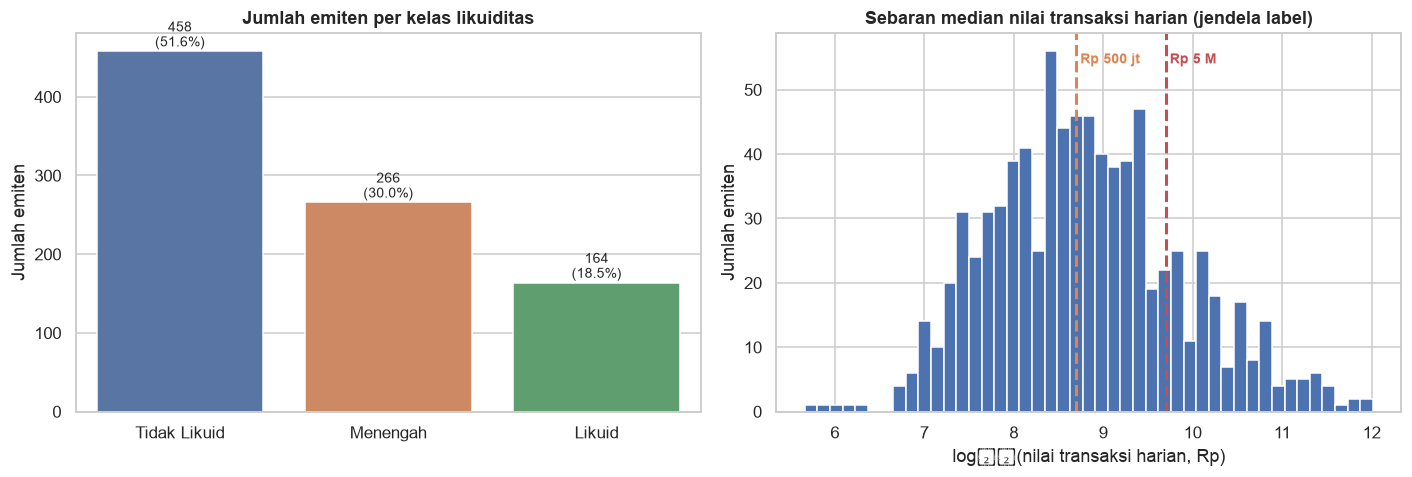

Proporsi kelas:
kelas_likuiditas
Tidak Likuid   51.6000
Menengah       30.0000
Likuid         18.5000

Emiten dengan median nilai transaksi tepat Rp 0 (saham benar-benar tidur): 55


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Kiri: jumlah emiten per kelas
hitung = df["kelas_likuiditas"].value_counts().reindex(URUTAN_KELAS)
sns.barplot(x=hitung.index, y=hitung.values, ax=axes[0], hue=hitung.index, legend=False)
axes[0].set_title("Jumlah emiten per kelas likuiditas")
axes[0].set_xlabel("")
axes[0].set_ylabel("Jumlah emiten")
for i, v in enumerate(hitung.values):
    axes[0].text(i, v + 6, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

# Kanan: sebaran nilai transaksi dalam skala logaritmik + garis ambang
positif = df.loc[df["advt_label"] > 0, "advt_label"]
axes[1].hist(np.log10(positif), bins=45, color="#4c72b0", edgecolor="white")
for ambang, warna, teks in [
    (AMBANG_MENENGAH, "#dd8452", "Rp 500 jt"),
    (AMBANG_LIKUID, "#c44e52", "Rp 5 M"),
]:
    axes[1].axvline(np.log10(ambang), color=warna, linestyle="--", linewidth=2)
    axes[1].text(np.log10(ambang), axes[1].get_ylim()[1] * 0.92, f" {teks}",
                 color=warna, fontsize=9, fontweight="bold")
axes[1].set_title("Sebaran median nilai transaksi harian (jendela label)")
axes[1].set_xlabel("log₁₀(nilai transaksi harian, Rp)")
axes[1].set_ylabel("Jumlah emiten")

plt.tight_layout()
plt.show()

print("Proporsi kelas:")
print((df["kelas_likuiditas"].value_counts(normalize=True).reindex(URUTAN_KELAS) * 100).round(1).to_string())
print()
print(f"Emiten dengan median nilai transaksi tepat Rp 0 (saham benar-benar tidur): "
      f"{(df['advt_label'] == 0).sum()}")

Sebaran nilai transaksi membentang lebih dari sepuluh kali lipat orde besaran —
karena itu sumbu horizontal digambar dalam skala logaritmik. Bentuk ini adalah
petunjuk awal bahwa fitur-fitur berbasis rupiah nantinya perlu ditransformasi
sebelum dipakai melatih model.

Kelas yang tidak seimbang (mayoritas **Tidak Likuid**) berarti **akurasi bukan metrik
yang memadai**: menebak kelas mayoritas untuk semua emiten sudah memberi akurasi di
atas 50%. Metrik yang dipakai pada kriteria berikutnya karenanya adalah **F1 makro**,
yang memberi bobot setara pada ketiga kelas.

### 4.3 Validasi silang label terhadap papan pencatatan BEI

Kolom `papan_pencatatan` **sengaja tidak dipakai sebagai fitur**. Salah satu dari
sebelas kriteria BEI untuk memindahkan emiten ke Papan Pemantauan Khusus adalah
likuiditas rendah — memakainya sebagai prediktor sama saja dengan membocorkan
jawaban.

Namun kolom ini sangat berharga sebagai **alat validasi independen**: jika definisi
label kita benar, emiten di Papan Pemantauan Khusus semestinya didominasi kelas
Tidak Likuid, tanpa model kita pernah melihat kolom tersebut.

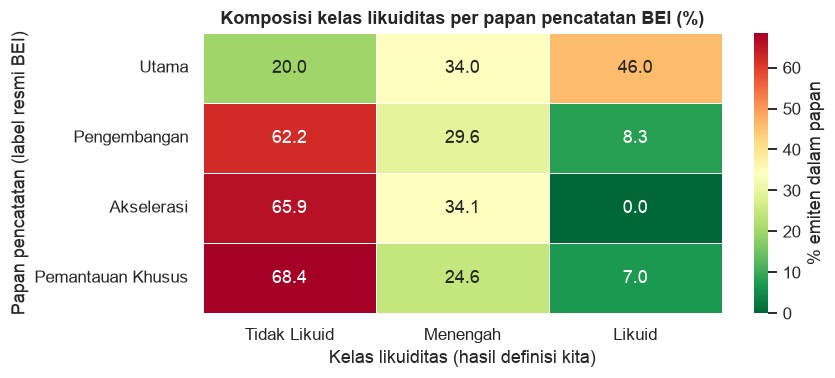

Jumlah emiten per papan:
papan_pencatatan
Pengembangan         423
Utama                250
Pemantauan Khusus    171
Akselerasi            41
Ekonomi Baru           3


In [15]:
papan_urut = ["Utama", "Pengembangan", "Akselerasi", "Pemantauan Khusus"]
papan_ada = [p for p in papan_urut if p in df["papan_pencatatan"].unique()]

tabel = pd.crosstab(df["papan_pencatatan"], df["kelas_likuiditas"], normalize="index") * 100
tabel = tabel.reindex(index=papan_ada, columns=URUTAN_KELAS)

fig, ax = plt.subplots(figsize=(8, 3.6))
sns.heatmap(tabel, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax,
            cbar_kws={"label": "% emiten dalam papan"}, linewidths=.5)
ax.set_title("Komposisi kelas likuiditas per papan pencatatan BEI (%)")
ax.set_xlabel("Kelas likuiditas (hasil definisi kita)")
ax.set_ylabel("Papan pencatatan (label resmi BEI)")
plt.tight_layout()
plt.show()

print("Jumlah emiten per papan:")
print(df["papan_pencatatan"].value_counts().to_string())

Hasilnya menegaskan definisi label kita sejalan dengan penilaian regulator: papan
**Pemantauan Khusus** dan **Akselerasi** didominasi emiten Tidak Likuid, sedangkan
papan **Utama** memiliki proporsi emiten Likuid yang jauh lebih tinggi. Kesesuaian
ini diperoleh tanpa kolom papan pernah masuk ke dalam perhitungan label.

### 4.4 Seberapa sulit masalah ini sebenarnya?

Sebelum melatih model apa pun, perlu ditetapkan **tolok ukur** yang harus dikalahkan.
Tolok ukur paling jujur di sini bukan tebakan acak, melainkan strategi naif yang
paling masuk akal: *"asumsikan kelas likuiditas tahun depan sama dengan tahun ini"*.

TOLOK UKUR YANG HARUS DIKALAHKAN MODEL
----------------------------------------------------
  Tebak kelas mayoritas untuk semua emiten :  51.6%
  Salin kelas dari tahun sebelumnya        :  73.9%



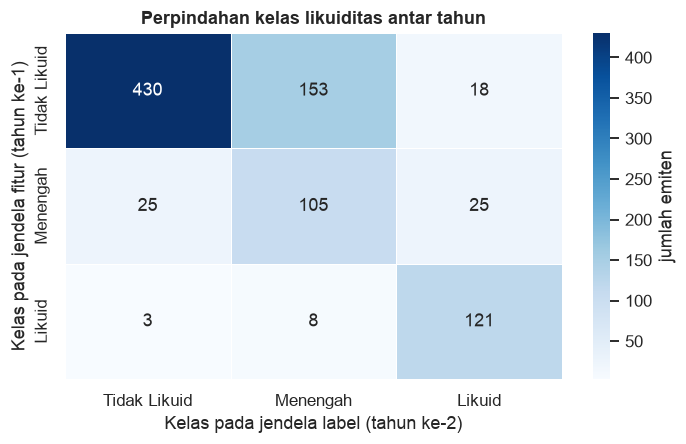

Emiten yang naik kelas   : 196
Emiten yang turun kelas  : 36
Emiten yang bertahan     : 656


In [16]:
def ke_kelas(nilai):
    if nilai >= AMBANG_LIKUID:
        return "Likuid"
    if nilai >= AMBANG_MENENGAH:
        return "Menengah"
    return "Tidak Likuid"


# Kelas seandainya dihitung dari jendela fitur (yaitu "kelas tahun lalu")
df["kelas_jendela_fitur"] = df["advt_median"].apply(ke_kelas)

akurasi_salin = (df["kelas_jendela_fitur"] == df["kelas_likuiditas"]).mean()
akurasi_mayoritas = df["kelas_likuiditas"].value_counts(normalize=True).max()

print("TOLOK UKUR YANG HARUS DIKALAHKAN MODEL")
print("-" * 52)
print(f"  Tebak kelas mayoritas untuk semua emiten : {akurasi_mayoritas*100:5.1f}%")
print(f"  Salin kelas dari tahun sebelumnya        : {akurasi_salin*100:5.1f}%")
print()

transisi = pd.crosstab(df["kelas_jendela_fitur"], df["kelas_likuiditas"]).reindex(
    index=URUTAN_KELAS, columns=URUTAN_KELAS, fill_value=0)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.heatmap(transisi, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=.5,
            cbar_kws={"label": "jumlah emiten"})
ax.set_title("Perpindahan kelas likuiditas antar tahun")
ax.set_xlabel("Kelas pada jendela label (tahun ke-2)")
ax.set_ylabel("Kelas pada jendela fitur (tahun ke-1)")
plt.tight_layout()
plt.show()

# Urutan kelas menaik: Tidak Likuid(0) -> Menengah(1) -> Likuid(2).
# Baris = kelas tahun ke-1, kolom = kelas tahun ke-2, sehingga sel di ATAS
# diagonal berarti kelas tahun ke-2 lebih tinggi, yaitu emiten naik kelas.
naik = int(np.triu(transisi.values, 1).sum())
turun = int(np.tril(transisi.values, -1).sum())
tetap = int(np.trace(transisi.values))
print(f"Emiten yang naik kelas   : {naik}")
print(f"Emiten yang turun kelas  : {turun}")
print(f"Emiten yang bertahan     : {tetap}")

Matriks perpindahan memperlihatkan dua hal yang penting bagi keseluruhan proyek.

Pertama, **masalah ini tidak sepele**. Strategi menyalin kelas tahun lalu sudah
mencapai akurasi tinggi, sehingga model baru dianggap berguna bila mampu
melampauinya — bukan sekadar melampaui tebakan acak.

Kedua, terlihat **arus perpindahan yang tidak simetris**: jauh lebih banyak emiten
yang naik kelas ketimbang yang turun. Likuiditas pasar secara keseluruhan meningkat
pada tahun kedua. Pergeseran semacam inilah yang membuat model machine learning
menjadi usang seiring waktu, dan menjadi alasan mengapa pelatihan ulang otomatis
serta pemantauan berkelanjutan pada kriteria berikutnya benar-benar diperlukan.

### 4.5 Sebaran fitur numerik dan kemencengan distribusi

In [17]:
kolom_fitur_numerik = [
    "advt_median", "advt_mean", "rasio_mean_median", "market_cap",
    "harga_median", "volume_median", "turnover_bps", "amihud_per_miliar",
    "volatilitas_tahunan", "rentang_harian_relatif", "max_drawdown", "beta_ihsg",
    "pct_hari_volume_nol", "pct_hari_harga_stagnan", "umur_listing_tahun",
    "jumlah_hari_bursa",
]

bersih = df[kolom_fitur_numerik].replace([np.inf, -np.inf], np.nan)

# Kemencengan dihitung dua kali dengan pustaka berbeda sebagai pemeriksaan silang.
banding = pd.DataFrame({
    "skew_pandas": bersih.skew(),
    "skew_scipy": {k: skew_scipy(bersih[k].dropna().to_numpy(), bias=False)
                   for k in kolom_fitur_numerik},
})
banding["selisih"] = (banding["skew_pandas"] - banding["skew_scipy"]).abs()
banding = banding.sort_values("skew_scipy", ascending=False)

print("Kemencengan (skewness) tiap fitur:")
print(banding.round(2).to_string())

mencurigakan = banding[banding["selisih"] > 0.5]
if len(mencurigakan):
    print("\n[PERIKSA] Kedua pustaka tidak sepakat pada fitur berikut:")
    print(mencurigakan.round(2).to_string())
else:
    print("\nKedua pustaka sepakat pada seluruh fitur.")

print("\nFitur dengan |skew| > 2 memerlukan transformasi sebelum pemodelan:")
print(banding.index[banding["skew_scipy"].abs() > 2].tolist())

Kemencengan (skewness) tiap fitur:
                        skew_pandas  skew_scipy  selisih
volume_median               24.4300     24.4300   0.0000
rasio_mean_median           15.9600     15.9600   0.0000
advt_median                 13.1500     13.1500   0.0000
advt_mean                   11.9900     11.9900   0.0000
market_cap                  11.1600     11.1600   0.0000
amihud_per_miliar            9.4500      9.4500   0.0000
harga_median                 9.1200      9.1200   0.0000
turnover_bps                 8.4700      8.4700   0.0000
pct_hari_volume_nol          3.7600      3.7600   0.0000
pct_hari_harga_stagnan       1.5000      1.5000   0.0000
beta_ihsg                    0.9000      0.9000   0.0000
volatilitas_tahunan          0.8900      0.8900   0.0000
umur_listing_tahun           0.7000      0.7000   0.0000
rentang_harian_relatif       0.3900      0.3900   0.0000
max_drawdown                -0.2800     -0.2800   0.0000
jumlah_hari_bursa          -13.8900    -13.8900   0.0

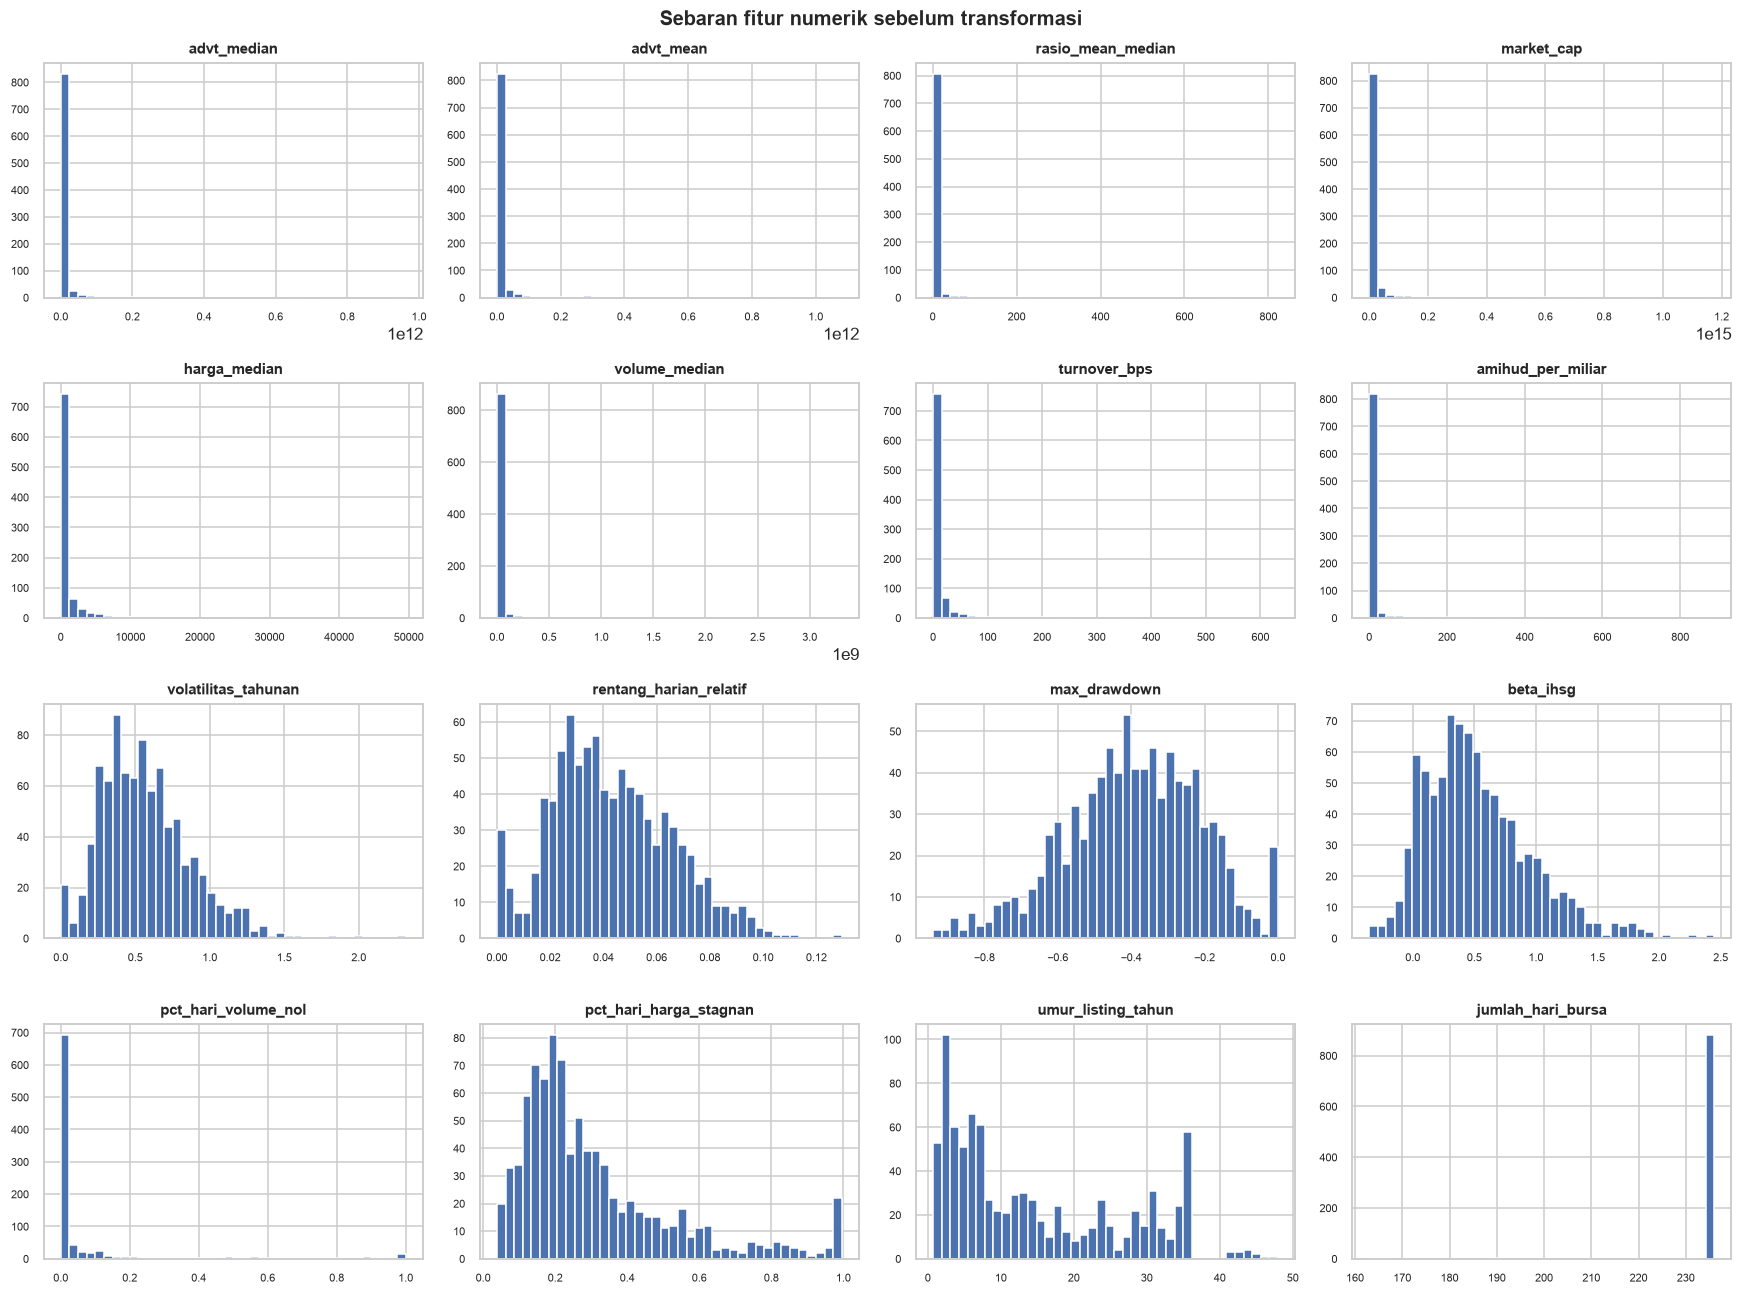

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, kolom in zip(axes.ravel(), kolom_fitur_numerik):
    data = df[kolom].replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(data, bins=40, color="#4c72b0", edgecolor="white")
    ax.set_title(kolom, fontsize=9.5)
    ax.tick_params(labelsize=7.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{int(v)}"))
fig.suptitle("Sebaran fitur numerik sebelum transformasi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Sebagian besar fitur berbasis rupiah sangat menceng ke kanan: mayoritas emiten
menumpuk di nilai kecil, sementara segelintir emiten raksasa berada sangat jauh di
ujung kanan. Bentuk ini akan ditangani dengan transformasi logaritmik pada tahap
preprocessing.

> **Catatan metodologis — mengapa kemencengan dihitung dua kali.**
> `pandas.Series.skew()` dapat mengembalikan `0.0` secara keliru untuk data yang
> magnitudonya sangat kecil. Fungsi internal `_zero_out_fperr` pada pandas
> menganggap jumlah kuadrat simpangan di bawah kira-kira `1e-14` sebagai galat
> pembulatan lalu menolkannya, sehingga rumus kemencengan menghasilkan nol.
> Pada rancangan awal fitur ini, rasio Amihud bernilai sekitar `1e-10` dalam satuan
> rupiah dan tepat terkena masalah tersebut: pandas melaporkan kemencengan `0.00`
> padahal nilai sebenarnya di atas `9`.
>
> Dua langkah diambil untuk mengatasinya. Pertama, satuan fitur diubah ke skala yang
> wajar (`amihud_per_miliar` dan `turnover_bps`) sehingga persoalan tidak muncul
> sejak awal. Kedua, hasil pandas tetap dibandingkan dengan `scipy.stats.skew`
> sebagai pengaman, agar kekeliruan serupa langsung terlihat alih-alih diam-diam
> memandu keputusan preprocessing ke arah yang salah.

### 4.6 Hubungan antar fitur dan dengan target

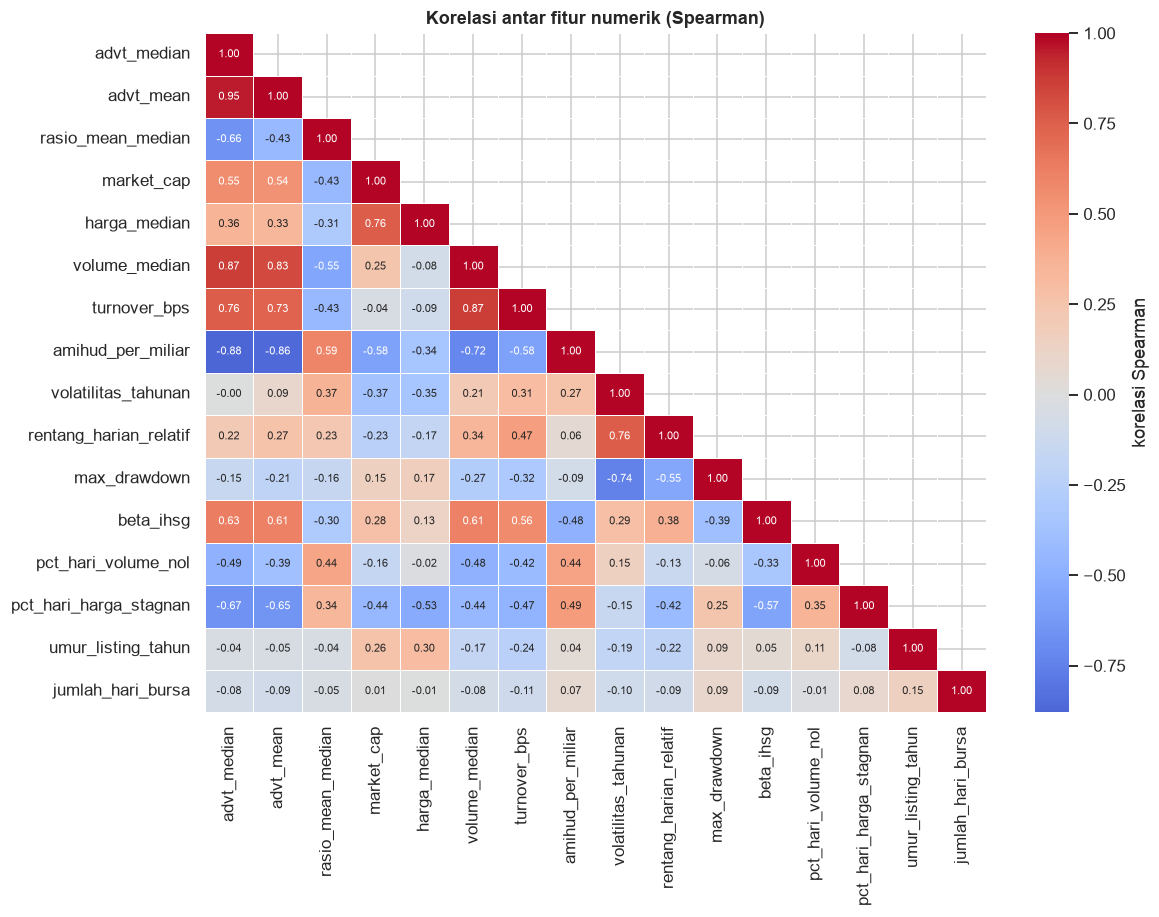

Pasangan fitur dengan |korelasi| > 0.85:
advt_median    advt_mean            0.9486
               amihud_per_miliar   -0.8797
volume_median  turnover_bps         0.8713
advt_median    volume_median        0.8658
advt_mean      amihud_per_miliar   -0.8639


In [19]:
korelasi = df[kolom_fitur_numerik].replace([np.inf, -np.inf], np.nan).corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 8.5))
segitiga = np.triu(np.ones_like(korelasi, dtype=bool), k=1)
sns.heatmap(korelasi, mask=segitiga, cmap="coolwarm", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 7}, linewidths=.4, ax=ax,
            cbar_kws={"label": "korelasi Spearman"})
ax.set_title("Korelasi antar fitur numerik (Spearman)")
plt.tight_layout()
plt.show()

# Pasangan fitur yang sangat berkorelasi -> kandidat redundan
pasangan = (korelasi.where(segitiga.T).unstack().dropna()
            .sort_values(key=abs, ascending=False))
kuat = pasangan[pasangan.abs() > 0.85]
print("Pasangan fitur dengan |korelasi| > 0.85:")
print(kuat.to_string() if len(kuat) else "(tidak ada pasangan sekuat itu)")

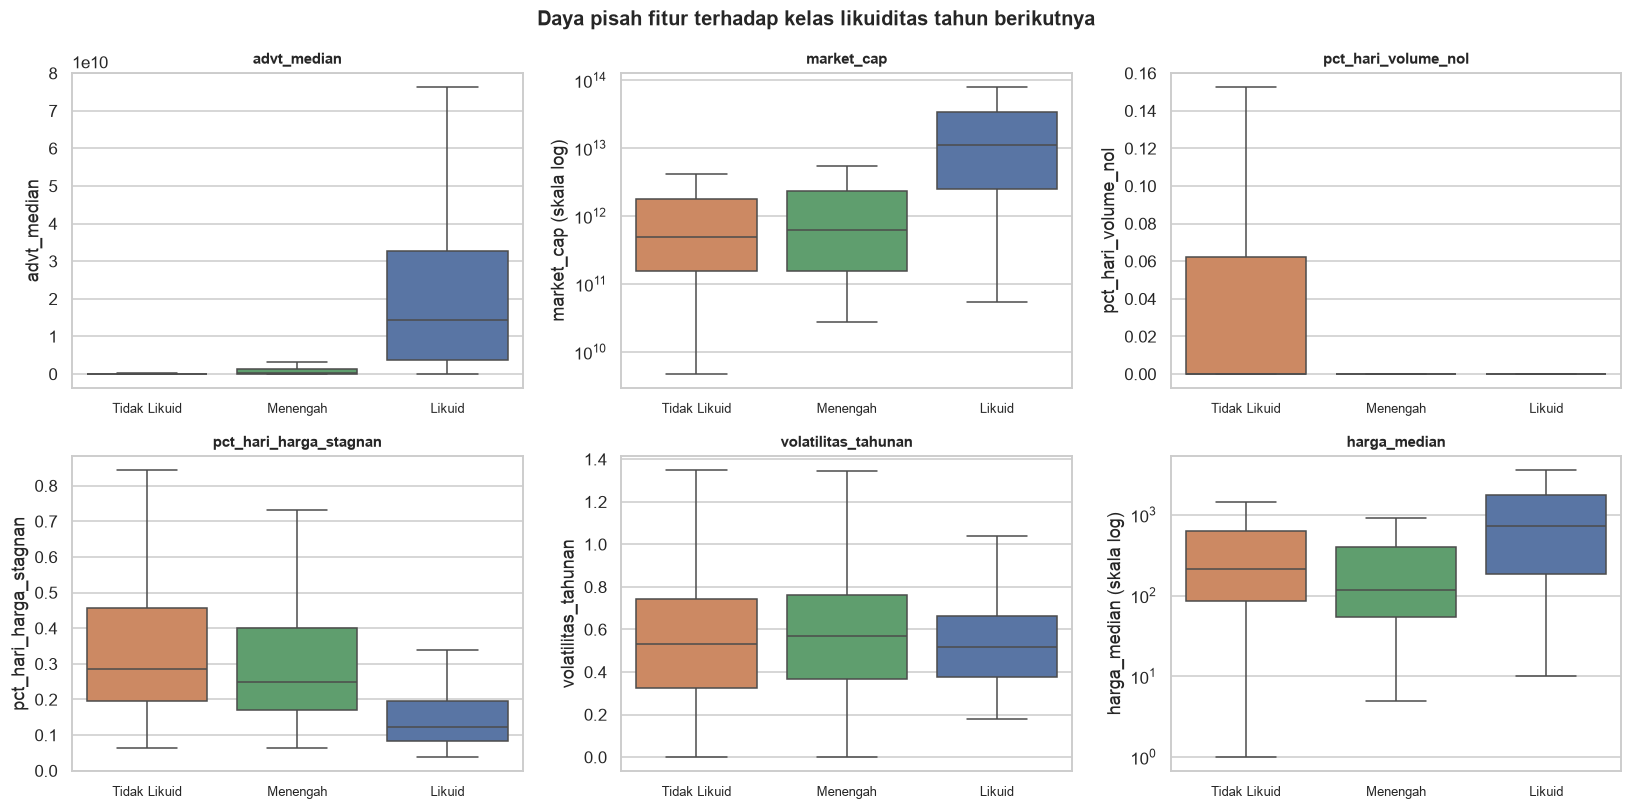

In [20]:
# Bagaimana tiap fitur membedakan ketiga kelas?
fitur_sorot = ["advt_median", "market_cap", "pct_hari_volume_nol",
               "pct_hari_harga_stagnan", "volatilitas_tahunan", "harga_median"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, kolom in zip(axes.ravel(), fitur_sorot):
    subset = df[["kelas_likuiditas", kolom]].replace([np.inf, -np.inf], np.nan).dropna()
    skala_log = subset[kolom].min() > 0 and subset[kolom].max() / max(subset[kolom].min(), 1e-12) > 1e3
    sns.boxplot(data=subset, x="kelas_likuiditas", y=kolom, order=URUTAN_KELAS,
                ax=ax, hue="kelas_likuiditas", legend=False, showfliers=False)
    if skala_log:
        ax.set_yscale("log")
        ax.set_ylabel(f"{kolom} (skala log)")
    ax.set_title(kolom, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=8.5)
fig.suptitle("Daya pisah fitur terhadap kelas likuiditas tahun berikutnya",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

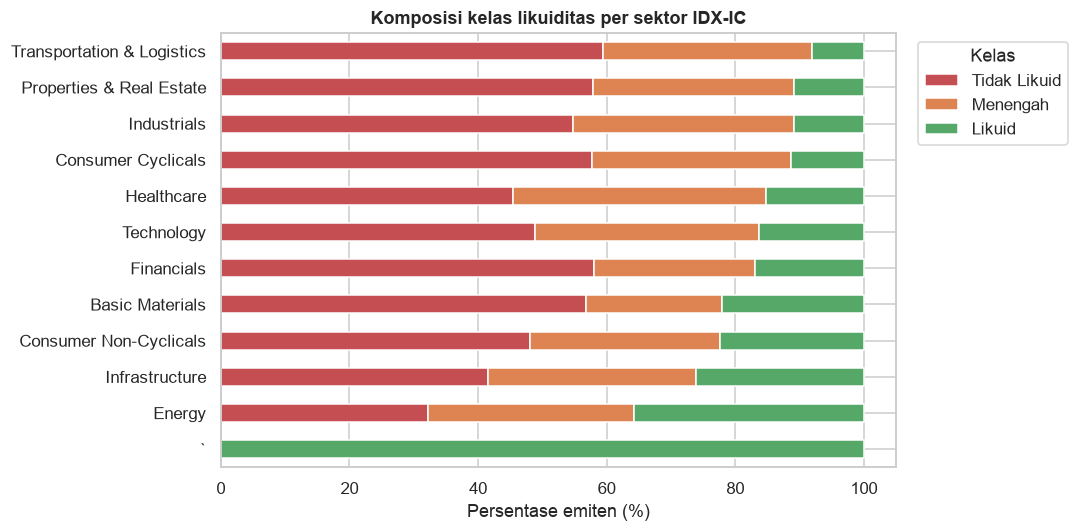

Jumlah emiten per sektor:
sektor
Consumer Cyclicals            149
Consumer Non-Cyclicals        125
Basic Materials               104
Financials                    100
Energy                         84
Properties & Real Estate       83
Infrastructure                 65
Industrials                    64
Technology                     43
Transportation & Logistics     37
Healthcare                     33
`                               1


In [21]:
# Komposisi kelas per sektor IDX-IC
komposisi = pd.crosstab(df["sektor"], df["kelas_likuiditas"], normalize="index") * 100
komposisi = komposisi.reindex(columns=URUTAN_KELAS).sort_values("Likuid", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
komposisi.plot(kind="barh", stacked=True, ax=ax,
               color=["#c44e52", "#dd8452", "#55a868"])
ax.set_title("Komposisi kelas likuiditas per sektor IDX-IC")
ax.set_xlabel("Persentase emiten (%)")
ax.set_ylabel("")
ax.legend(title="Kelas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Jumlah emiten per sektor:")
print(df["sektor"].value_counts().to_string())

Grafik sektor memperlihatkan satu kategori yang tidak valid — artefak dari penguraian
tabel Wikipedia. Kotoran ini akan dibersihkan pada tahap preprocessing.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Urutan langkah di bawah mengikuti daftar pada template, dengan penyesuaian terhadap
karakter data keuangan yang kita hadapi.

Satu prinsip dipegang di sepanjang tahap ini: **setiap parameter yang dipelajari dari
data — median untuk pengisian nilai kosong, batas pemangkasan outlier, rata-rata dan
simpangan baku untuk standarisasi — hanya boleh dihitung dari data latih.** Data uji
diperlakukan seolah-olah baru pertama kali terlihat. Karena itu pemisahan data latih
dan uji dilakukan lebih awal, sebelum transformasi apa pun diterapkan.

In [22]:
# Salinan kerja agar tabel hasil EDA tetap utuh untuk rujukan
data = df.copy()
print(f"Titik awal preprocessing: {data.shape[0]} baris x {data.shape[1]} kolom")

Titik awal preprocessing: 888 baris x 26 kolom


### 5.0 Membersihkan kategori sektor yang tidak valid

EDA menemukan satu nilai sektor berupa karakter aksen — artefak penguraian tabel HTML.
Karena hanya menyangkut sedikit emiten, nilai tersebut dipetakan ke kategori
`Tidak Diketahui` alih-alih membuang barisnya, agar informasi fitur lain tidak hilang.

In [23]:
SEKTOR_VALID = {
    "Basic Materials", "Consumer Cyclicals", "Consumer Non-Cyclicals", "Energy",
    "Financials", "Healthcare", "Industrials", "Infrastructure",
    "Properties & Real Estate", "Technology", "Transportation & Logistics",
}

sebelum = data["sektor"].nunique()
tidak_valid = sorted(set(data["sektor"].dropna().unique()) - SEKTOR_VALID)
print(f"Kategori sektor tidak valid yang ditemukan: {tidak_valid}")
print(f"Jumlah emiten terdampak: {data['sektor'].isin(tidak_valid).sum()}")

data["sektor"] = data["sektor"].where(data["sektor"].isin(SEKTOR_VALID), "Tidak Diketahui")
data["sektor"] = data["sektor"].fillna("Tidak Diketahui")

print(f"\nKategori sektor: {sebelum} -> {data['sektor'].nunique()}")
print(data["sektor"].value_counts().to_string())

Kategori sektor tidak valid yang ditemukan: ['`']
Jumlah emiten terdampak: 1

Kategori sektor: 12 -> 12
sektor
Consumer Cyclicals            149
Consumer Non-Cyclicals        125
Basic Materials               104
Financials                    100
Energy                         84
Properties & Real Estate       83
Infrastructure                 65
Industrials                    64
Technology                     43
Transportation & Logistics     37
Healthcare                     33
Tidak Diketahui                 1


### 5.1 Menangani nilai tak hingga dan nilai kosong

Rasio Amihud dan `rasio_mean_median` dapat menghasilkan nilai tak hingga ketika
penyebutnya nol — yaitu pada emiten yang benar-benar tidak diperdagangkan. Nilai
semacam ini diubah menjadi kosong terlebih dahulu, lalu diisi bersama nilai kosong
lain memakai median data latih.

In [24]:
KOLOM_NUMERIK = [
    "advt_median", "advt_mean", "rasio_mean_median", "market_cap",
    "harga_median", "volume_median", "turnover_bps", "amihud_per_miliar",
    "volatilitas_tahunan", "rentang_harian_relatif", "max_drawdown", "beta_ihsg",
    "pct_hari_volume_nol", "pct_hari_harga_stagnan", "umur_listing_tahun",
    "jumlah_hari_bursa",
]
KOLOM_KATEGORIK = ["sektor"]
KOLOM_TARGET = "kelas_likuiditas"

# Kolom identitas & validasi — disimpan untuk penelusuran, tidak ikut dilatih
KOLOM_IDENTITAS = ["kode", "nama_perusahaan", "papan_pencatatan", "advt_label"]

jml_inf = int(np.isinf(data[KOLOM_NUMERIK].to_numpy(dtype=float)).sum())
data[KOLOM_NUMERIK] = data[KOLOM_NUMERIK].replace([np.inf, -np.inf], np.nan)

print(f"Nilai tak hingga yang diubah menjadi kosong: {jml_inf}")
print()
print("Nilai kosong per kolom sebelum pengisian:")
kosong = data[KOLOM_NUMERIK].isna().sum()
print(kosong[kosong > 0].to_string() if kosong.sum() else "(tidak ada)")

Nilai tak hingga yang diubah menjadi kosong: 0

Nilai kosong per kolom sebelum pengisian:
rasio_mean_median    45
amihud_per_miliar    15


### 5.2 Menghapus data duplikat

Setiap baris merepresentasikan satu emiten, sehingga kode emiten wajib unik.

In [25]:
sebelum = len(data)
data = data.drop_duplicates(subset=["kode"], keep="first")
data = data.drop_duplicates()
print(f"Baris duplikat dihapus : {sebelum - len(data)}")
print(f"Jumlah baris sekarang  : {len(data)}")
print(f"Kode emiten unik       : {data['kode'].nunique()}")

Baris duplikat dihapus : 0
Jumlah baris sekarang  : 888
Kode emiten unik       : 888


### 5.3 Memisahkan data latih dan data uji

Pemisahan dilakukan **sebelum** pengisian nilai kosong, pemangkasan outlier, dan
standarisasi, sehingga tidak ada statistik data uji yang merembes ke proses pelatihan.
Pembagian dibuat **berstrata** agar proporsi ketiga kelas terjaga di kedua bagian.

In [26]:
X = data[KOLOM_NUMERIK + KOLOM_KATEGORIK].copy()
y = data[KOLOM_TARGET].copy()
identitas = data[KOLOM_IDENTITAS].copy()

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, identitas,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Data latih : {X_train.shape[0]} baris")
print(f"Data uji   : {X_test.shape[0]} baris")
print()
print("Proporsi kelas (%):")
print(pd.DataFrame({
    "latih": y_train.value_counts(normalize=True).reindex(URUTAN_KELAS) * 100,
    "uji":   y_test.value_counts(normalize=True).reindex(URUTAN_KELAS) * 100,
}).round(2).to_string())

Data latih : 710 baris
Data uji   : 178 baris

Proporsi kelas (%):
                   latih     uji
kelas_likuiditas                
Tidak Likuid     51.5500 51.6900
Menengah         30.0000 29.7800
Likuid           18.4500 18.5400


### 5.4 Mengisi nilai kosong dengan median data latih

Median dipilih karena distribusi fitur sangat menceng — rata-rata akan tertarik oleh
segelintir emiten raksasa.

In [27]:
median_latih = X_train[KOLOM_NUMERIK].median()

X_train[KOLOM_NUMERIK] = X_train[KOLOM_NUMERIK].fillna(median_latih)
X_test[KOLOM_NUMERIK] = X_test[KOLOM_NUMERIK].fillna(median_latih)   # median DATA LATIH

print("Nilai median data latih yang dipakai sebagai pengisi:")
print(median_latih.to_string())
print()
print(f"Sisa nilai kosong di data latih : {X_train.isna().sum().sum()}")
print(f"Sisa nilai kosong di data uji   : {X_test.isna().sum().sum()}")

Nilai median data latih yang dipakai sebagai pengisi:
advt_median                  121,305,500.0000
advt_mean                    416,426,201.0593
rasio_mean_median                      2.7560
market_cap               962,485,000,000.0000
harga_median                         216.0000
volume_median                    751,900.0000
turnover_bps                           2.0198
amihud_per_miliar                      0.1857
volatilitas_tahunan                    0.5319
rentang_harian_relatif                 0.0396
max_drawdown                          -0.3864
beta_ihsg                              0.4440
pct_hari_volume_nol                    0.0000
pct_hari_harga_stagnan                 0.2331
umur_listing_tahun                    11.0637
jumlah_hari_bursa                    236.0000

Sisa nilai kosong di data latih : 0
Sisa nilai kosong di data uji   : 0


### 5.5 Deteksi dan penanganan outlier

Outlier di sini **bukan kesalahan pencatatan** — saham berkapitalisasi raksasa memang
benar-benar bernilai transaksi ribuan kali lipat saham kecil. Membuangnya berarti
membuang justru emiten terpenting di bursa.

Karena itu dipakai **pemangkasan (*winsorizing*)** pada persentil 1 dan 99 alih-alih
penghapusan baris: nilai ekstrem ditarik ke batas, sehingga barisnya tetap ada namun
pengaruhnya pada model tidak berlebihan. Batas dihitung dari data latih saja.

In [28]:
batas_bawah = X_train[KOLOM_NUMERIK].quantile(0.01)
batas_atas = X_train[KOLOM_NUMERIK].quantile(0.99)

def hitung_outlier(frame: pd.DataFrame) -> pd.Series:
    di_luar = (frame[KOLOM_NUMERIK] < batas_bawah) | (frame[KOLOM_NUMERIK] > batas_atas)
    return di_luar.sum()

outlier_sebelum = hitung_outlier(X_train)

X_train[KOLOM_NUMERIK] = X_train[KOLOM_NUMERIK].clip(batas_bawah, batas_atas, axis=1)
X_test[KOLOM_NUMERIK] = X_test[KOLOM_NUMERIK].clip(batas_bawah, batas_atas, axis=1)

print("Jumlah nilai yang dipangkas per fitur (data latih):")
print(outlier_sebelum[outlier_sebelum > 0].to_string())
print(f"\nTotal nilai dipangkas: {int(outlier_sebelum.sum())} "
      f"dari {X_train[KOLOM_NUMERIK].size} sel ({outlier_sebelum.sum()/X_train[KOLOM_NUMERIK].size*100:.2f}%)")
print(f"Jumlah baris tetap utuh: {len(X_train)} baris latih, {len(X_test)} baris uji")

Jumlah nilai yang dipangkas per fitur (data latih):
advt_median                8
advt_mean                  8
rasio_mean_median         16
market_cap                16
harga_median              14
volume_median              8
turnover_bps               8
amihud_per_miliar         16
volatilitas_tahunan        8
rentang_harian_relatif     8
max_drawdown               8
beta_ihsg                 16
pct_hari_harga_stagnan     6
umur_listing_tahun        16
jumlah_hari_bursa          6

Total nilai dipangkas: 162 dari 11360 sel (1.43%)
Jumlah baris tetap utuh: 710 baris latih, 178 baris uji


### 5.6 Transformasi logaritmik pada fitur yang menceng

EDA menunjukkan fitur berbasis rupiah membentang lebih dari sepuluh orde besaran.
Transformasi `log1p` memampatkan rentang tersebut menjadi mendekati simetris,
sehingga model berbasis jarak maupun model linear dapat bekerja wajar.

Transformasi hanya diterapkan pada fitur bernilai non-negatif; `max_drawdown` dan
`beta_ihsg` yang dapat bernilai negatif dibiarkan apa adanya.

In [29]:
KOLOM_LOG = [
    "advt_median", "advt_mean", "market_cap", "harga_median",
    "volume_median", "turnover_bps", "amihud_per_miliar",
    "rasio_mean_median", "volatilitas_tahunan",
]

def kemencengan(frame: pd.DataFrame, kolom: list[str]) -> pd.Series:
    """Kemencengan memakai scipy agar bebas dari masalah presisi pandas."""
    return pd.Series(
        {k: skew_scipy(frame[k].dropna().to_numpy(), bias=False) for k in kolom}
    )

skew_sebelum = kemencengan(X_train, KOLOM_LOG)

for kolom in KOLOM_LOG:
    X_train[kolom] = np.log1p(X_train[kolom].clip(lower=0))
    X_test[kolom] = np.log1p(X_test[kolom].clip(lower=0))

skew_sesudah = kemencengan(X_train, KOLOM_LOG)

hasil = pd.DataFrame({
    "sebelum": skew_sebelum.round(2),
    "sesudah": skew_sesudah.round(2),
    "perbaikan": (skew_sebelum.abs() - skew_sesudah.abs()).round(2),
}).sort_values("perbaikan", ascending=False)

print("Perubahan kemencengan setelah transformasi log1p:")
print(hasil.to_string())

tetap_menceng = hasil.index[hasil["sesudah"].abs() > 2].tolist()
print(f"\nFitur yang masih |skew| > 2 setelah transformasi: "
      f"{tetap_menceng if tetap_menceng else '(tidak ada)'}")

Perubahan kemencengan setelah transformasi log1p:
                     sebelum  sesudah  perbaikan
market_cap            5.9400   0.3700     5.5700
amihud_per_miliar     6.7900   1.9900     4.8000
turnover_bps          5.3300   0.8800     4.4600
advt_median           5.6600  -2.1000     3.5600
rasio_mean_median     5.3400   1.8700     3.4700
harga_median          3.6900   0.2500     3.4300
advt_mean             5.7000  -2.4200     3.2800
volume_median         4.8300  -1.6000     3.2300
volatilitas_tahunan   0.5100   0.0600     0.4500

Fitur yang masih |skew| > 2 setelah transformasi: ['advt_median', 'advt_mean']


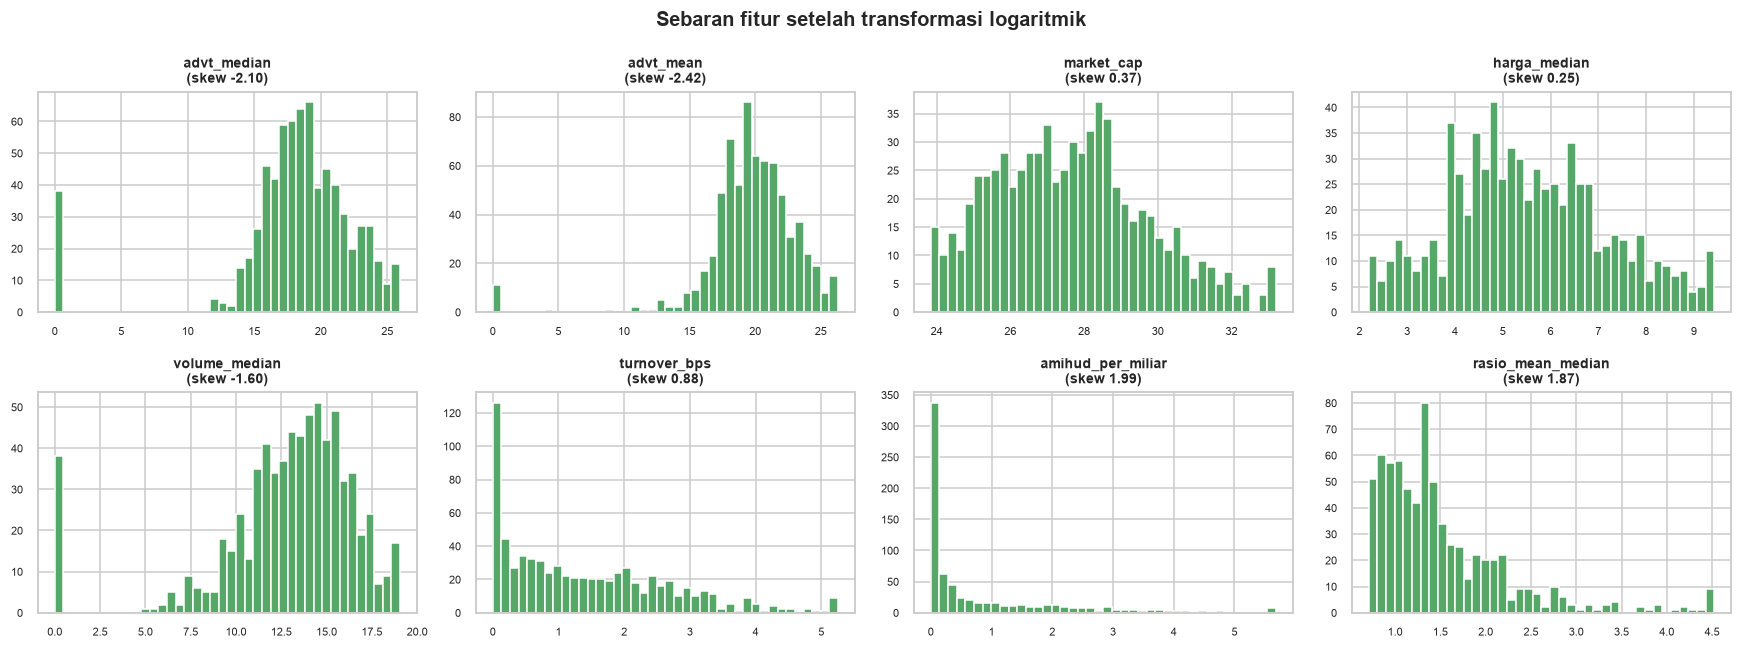

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, kolom in zip(axes.ravel(), KOLOM_LOG[:8]):
    ax.hist(X_train[kolom], bins=40, color="#55a868", edgecolor="white")
    ax.set_title(f"{kolom}\n(skew {X_train[kolom].skew():.2f})", fontsize=9)
    ax.tick_params(labelsize=7.5)
fig.suptitle("Sebaran fitur setelah transformasi logaritmik",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Transformasi berhasil menekan kemencengan pada hampir seluruh fitur. Dua fitur —
`advt_median` dan `advt_mean` — justru berbalik menjadi menceng negatif, dan ini
**bukan kegagalan transformasi melainkan cerminan struktur pasar**.

Terdapat puluhan emiten yang median nilai transaksi hariannya benar-benar nol
sepanjang jendela pengamatan. Bagi kelompok itu `log1p(0)` menghasilkan tepat nol,
sementara emiten lain tersebar di sekitar nilai 20-an. Sebarannya karenanya menjadi
dua gunung: satu tumpukan di nol untuk saham yang sama sekali tidak diperdagangkan,
dan satu sebaran normal untuk sisanya.

Bentuk ini dibiarkan apa adanya. Memaksakan transformasi lain hanya akan mengaburkan
perbedaan yang justru paling ingin dipelajari model, yaitu batas antara saham yang
diperdagangkan dan saham yang benar-benar mati. Informasi itu juga sudah ditangkap
secara eksplisit oleh fitur `pct_hari_volume_nol`.

### 5.7 Encoding fitur kategorikal

Sektor IDX-IC tidak memiliki urutan alami, sehingga dipakai **one-hot encoding**.
Parameter `handle_unknown="ignore"` membuat encoder tidak gagal bila kelak muncul
sektor baru saat model dijalankan di produksi — pertimbangan penting karena pipeline
ini akan dijalankan ulang secara otomatis pada kriteria berikutnya.

In [31]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.int8)
encoder.fit(X_train[KOLOM_KATEGORIK])

nama_kolom_ohe = encoder.get_feature_names_out(KOLOM_KATEGORIK).tolist()

def terapkan_ohe(frame: pd.DataFrame) -> pd.DataFrame:
    hasil = pd.DataFrame(
        encoder.transform(frame[KOLOM_KATEGORIK]),
        columns=nama_kolom_ohe,
        index=frame.index,
    )
    return pd.concat([frame.drop(columns=KOLOM_KATEGORIK), hasil], axis=1)

X_train = terapkan_ohe(X_train)
X_test = terapkan_ohe(X_test)

print(f"Kolom hasil one-hot encoding ({len(nama_kolom_ohe)}):")
for nama in nama_kolom_ohe:
    print("  -", nama)
print()
print(f"Dimensi data latih : {X_train.shape}")
print(f"Dimensi data uji   : {X_test.shape}")

Kolom hasil one-hot encoding (12):
  - sektor_Basic Materials
  - sektor_Consumer Cyclicals
  - sektor_Consumer Non-Cyclicals
  - sektor_Energy
  - sektor_Financials
  - sektor_Healthcare
  - sektor_Industrials
  - sektor_Infrastructure
  - sektor_Properties & Real Estate
  - sektor_Technology
  - sektor_Tidak Diketahui
  - sektor_Transportation & Logistics

Dimensi data latih : (710, 28)
Dimensi data uji   : (178, 28)


### 5.8 Standarisasi fitur numerik

`StandardScaler` menyetel setiap fitur numerik ke rata-rata 0 dan simpangan baku 1.
Kolom hasil one-hot dibiarkan dalam bentuk 0/1 agar tetap dapat dibaca manusia.
Sekali lagi, penyetelan hanya dipelajari dari data latih.

In [32]:
scaler = StandardScaler()
scaler.fit(X_train[KOLOM_NUMERIK])

X_train[KOLOM_NUMERIK] = scaler.transform(X_train[KOLOM_NUMERIK])
X_test[KOLOM_NUMERIK] = scaler.transform(X_test[KOLOM_NUMERIK])

print("Statistik data latih setelah standarisasi (harus ~0 dan ~1):")
print(X_train[KOLOM_NUMERIK].agg(["mean", "std"]).T.round(4).to_string())
print()
print("Statistik data uji (boleh sedikit menyimpang — itu wajar dan benar):")
print(X_test[KOLOM_NUMERIK].agg(["mean", "std"]).T.round(4).to_string())

Statistik data latih setelah standarisasi (harus ~0 dan ~1):
                          mean    std
advt_median             0.0000 1.0007
advt_mean               0.0000 1.0007
rasio_mean_median      -0.0000 1.0007
market_cap             -0.0000 1.0007
harga_median           -0.0000 1.0007
volume_median           0.0000 1.0007
turnover_bps            0.0000 1.0007
amihud_per_miliar      -0.0000 1.0007
volatilitas_tahunan    -0.0000 1.0007
rentang_harian_relatif  0.0000 1.0007
max_drawdown            0.0000 1.0007
beta_ihsg               0.0000 1.0007
pct_hari_volume_nol     0.0000 1.0007
pct_hari_harga_stagnan  0.0000 1.0007
umur_listing_tahun     -0.0000 1.0007
jumlah_hari_bursa       0.0000 0.0000

Statistik data uji (boleh sedikit menyimpang — itu wajar dan benar):
                          mean    std
advt_median             0.0224 0.9126
advt_mean              -0.0207 1.0010
rasio_mean_median       0.0287 1.0200
market_cap             -0.1621 0.9514
harga_median           -0.1141 0.

### 5.9 Binning: pengelompokan target

Target sendiri sudah merupakan hasil *binning* — median nilai transaksi harian yang
kontinu dipetakan ke tiga kelas menggunakan ambang absolut. Langkah ini telah
dilakukan saat pembentukan label pada bagian 3.

Untuk pemodelan, label teks diubah menjadi kode numerik berurut. Urutan ditetapkan
secara eksplisit (`Tidak Likuid` → 0, `Menengah` → 1, `Likuid` → 2) agar konsisten
antara notebook, berkas otomatisasi, dan tahap pelatihan model.

In [33]:
PETA_KELAS = {nama: idx for idx, nama in enumerate(URUTAN_KELAS)}

y_train_kode = y_train.map(PETA_KELAS).astype(int)
y_test_kode = y_test.map(PETA_KELAS).astype(int)

print("Pemetaan kelas:")
for nama, kode in PETA_KELAS.items():
    print(f"  {kode} = {nama}")
print()
print("Sebaran label:")
print(pd.DataFrame({
    "latih": y_train_kode.value_counts().sort_index(),
    "uji": y_test_kode.value_counts().sort_index(),
}).rename(index={v: k for k, v in PETA_KELAS.items()}).to_string())

Pemetaan kelas:
  0 = Tidak Likuid
  1 = Menengah
  2 = Likuid

Sebaran label:
                  latih  uji
kelas_likuiditas            
Tidak Likuid        366   92
Menengah            213   53
Likuid              131   33


### 5.10 Menyimpan dataset hasil preprocessing

Keluaran disimpan dalam tiga bentuk agar dapat langsung dipakai pada kriteria
berikutnya:

- `idx_liquidity_train.csv` dan `idx_liquidity_test.csv` — data siap latih, sudah dipisah;
- `idx_liquidity_preprocessed.csv` — gabungan keduanya dengan penanda bagian, untuk penelusuran;
- `metadata_preprocessing.json` — seluruh parameter yang dipelajari dari data latih,
  supaya data baru di masa depan dapat ditransformasi dengan cara yang persis sama.

In [34]:
train_out = X_train.copy()
train_out["kelas_likuiditas"] = y_train.values
train_out["kelas_kode"] = y_train_kode.values
train_out.insert(0, "kode", id_train["kode"].values)

test_out = X_test.copy()
test_out["kelas_likuiditas"] = y_test.values
test_out["kelas_kode"] = y_test_kode.values
test_out.insert(0, "kode", id_test["kode"].values)

train_out.to_csv(DIR_OUT / "idx_liquidity_train.csv", index=False)
test_out.to_csv(DIR_OUT / "idx_liquidity_test.csv", index=False)

gabungan = pd.concat(
    [train_out.assign(bagian="train"), test_out.assign(bagian="test")],
    ignore_index=True,
)
gabungan.to_csv(DIR_OUT / "idx_liquidity_preprocessed.csv", index=False)

print(f"idx_liquidity_train.csv        : {train_out.shape}")
print(f"idx_liquidity_test.csv         : {test_out.shape}")
print(f"idx_liquidity_preprocessed.csv : {gabungan.shape}")
train_out.head()

idx_liquidity_train.csv        : (710, 31)
idx_liquidity_test.csv         : (178, 31)
idx_liquidity_preprocessed.csv : (888, 32)


,kode,advt_median,advt_mean,rasio_mean_median,market_cap,harga_median,volume_median,turnover_bps,amihud_per_miliar,volatilitas_tahunan,rentang_harian_relatif,max_drawdown,beta_ihsg,pct_hari_volume_nol,pct_hari_harga_stagnan,umur_listing_tahun,jumlah_hari_bursa,sektor_Basic Materials,sektor_Consumer Cyclicals,sektor_Consumer Non-Cyclicals,sektor_Energy,sektor_Financials,sektor_Healthcare,sektor_Industrials,sektor_Infrastructure,sektor_Properties & Real Estate,sektor_Technology,sektor_Tidak Diketahui,sektor_Transportation & Logistics,kelas_likuiditas,kelas_kode
825,TRIN,-0.0530,-0.1753,0.0515,-0.3460,-0.4983,0.0836,-0.5088,-0.3275,0.1339,0.7524,-0.5828,-0.1766,-0.3418,-0.6210,-0.7768,0.0000,0,0,0,0,0,0,0,0,1,0,0,0,Menengah,1
668,PTDU,-0.6796,-1.1254,-0.2403,-1.7725,-1.6002,-0.2736,-0.6388,1.7477,0.6999,-1.1410,-1.8594,-0.8625,0.2092,1.0569,-0.8531,0.0000,0,0,0,0,0,0,0,1,0,0,0,0,Tidak Likuid,0
608,OMED,0.2998,0.1476,-0.5720,0.7332,-0.2156,0.3999,-0.7018,-0.6086,-1.3375,-0.8540,1.0510,-0.5382,-0.3418,-0.2698,-1.0158,0.0000,0,0,0,0,0,1,0,0,0,0,0,0,Menengah,1
481,LINK,-0.1579,-0.2535,0.3298,0.7101,1.1127,-0.7266,-1.0680,0.1638,0.7982,0.2102,-0.5412,-1.6208,-0.2536,-0.4650,-0.2995,0.0000,0,0,0,0,0,0,0,1,0,0,0,0,Tidak Likuid,0
788,TARA,-0.4849,-0.8217,-0.1194,-1.1144,-1.8985,0.0951,-0.7744,2.1644,1.5582,0.8539,-0.2073,-1.0393,-0.3418,1.3105,-0.3086,0.0000,0,0,0,0,0,0,0,0,1,0,0,0,Tidak Likuid,0


In [35]:
meta_prep = {
    "sumber_dataset": "IDX via yfinance + profil emiten Wikipedia",
    "jendela_fitur": {"mulai": JENDELA_FITUR[0], "selesai": JENDELA_FITUR[1]},
    "jendela_label": {"mulai": JENDELA_LABEL[0], "selesai": JENDELA_LABEL[1]},
    "min_hari_bursa": MIN_HARI_BURSA,
    "ambang_kelas_rupiah": {"likuid": AMBANG_LIKUID, "menengah": AMBANG_MENENGAH},
    "urutan_kelas": URUTAN_KELAS,
    "peta_kelas": PETA_KELAS,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "kolom_numerik": KOLOM_NUMERIK,
    "kolom_log1p": KOLOM_LOG,
    "kolom_kategorik": KOLOM_KATEGORIK,
    "kolom_ohe": nama_kolom_ohe,
    "kolom_fitur_final": X_train.columns.tolist(),
    "sektor_valid": sorted(SEKTOR_VALID),
    "parameter_dipelajari_dari_data_latih": {
        "median_pengisi": median_latih.to_dict(),
        "batas_bawah_winsor_p01": batas_bawah.to_dict(),
        "batas_atas_winsor_p99": batas_atas.to_dict(),
        "scaler_mean": dict(zip(KOLOM_NUMERIK, scaler.mean_.tolist())),
        "scaler_scale": dict(zip(KOLOM_NUMERIK, scaler.scale_.tolist())),
    },
    "jumlah_baris": {"latih": int(len(train_out)), "uji": int(len(test_out))},
}

(DIR_OUT / "metadata_preprocessing.json").write_text(
    json.dumps(meta_prep, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("Berkas yang dihasilkan:")
for berkas in sorted(DIR_OUT.iterdir()):
    print(f"  {berkas.name:<34} {berkas.stat().st_size/1024:>9,.1f} KB")

Berkas yang dihasilkan:
  idx_liquidity_preprocessed.csv         301.4 KB
  idx_liquidity_test.csv                  59.9 KB
  idx_liquidity_train.csv                237.0 KB
  metadata_preprocessing.json              6.1 KB


---

## Ringkasan tahapan

| Tahap | Hasil |
|---|---|
| Data mentah | 427.567 baris panel harian, 941 emiten terdaftar |
| Rekayasa fitur | 16 fitur level emiten dari jendela Agu 2024 – Jul 2025 |
| Pembentukan label | 3 kelas likuiditas dari jendela Agu 2025 – Jul 2026 |
| Penyaringan | emiten dengan hari bursa memadai di kedua jendela |
| Preprocessing | pembersihan sektor → penanganan nilai kosong → pemisahan latih/uji → pengisian median → pemangkasan outlier → transformasi log → one-hot → standarisasi |
| Keluaran | data latih & uji siap pakai, beserta metadata parameter transformasi |

Tolok ukur yang harus dilampaui model pada kriteria berikutnya adalah **akurasi
strategi menyalin kelas tahun sebelumnya**, bukan sekadar tebakan mayoritas.

Seluruh langkah pada bagian 5 telah dikonversi menjadi berkas otomatisasi
`automate_Septian-Maulana.py`, yang menjalankan urutan yang sama dari data mentah
hingga data siap latih tanpa campur tangan manual.